# 09 — Lie Groups & Lie Algebras

> *How to do calculus on a curved space of symmetries — by flattening it exactly once, at the identity.*

## The one-paragraph answer

Rotations form a **group**, not a vector space. You cannot add two rotations, average them,
take a gradient step in them, or interpolate between them — the result simply is not a
rotation. That breaks every tool you own.

A **Lie algebra** is the fix: the tangent space at the identity of the group. It **is** a
flat vector space, so all your linear machinery works there, and the matrix exponential maps
it back onto the curved group. You do the calculus downstairs where it is flat, then push the
answer upstairs.

The one extra piece of structure is the **commutator** $[A,B] = AB - BA$. It is there
because the group is non-commutative, and it records exactly *how much* — to first order,
$e^Ae^B e^{-A}e^{-B} \approx e^{[A,B]}$. A vector space closed under such a bracket is a
Lie algebra.

## Relation to notebook 08

Notebook 08 built the ladder metric $\to$ normed $\to$ Banach $\to$ Hilbert. That ladder asks
*how much geometry does a space have?* This is a **different axis**:

| | Notebook 08 | This notebook |
|---|---|---|
| Question | geometry in infinite dimensions | calculus on a curved **group** |
| Object | vector space + inner product | tangent space at the identity of a manifold |
| Key operation | $\langle u,v\rangle$ | $[A,B] = AB-BA$ |
| Where they meet | — | groups **act on** Hilbert spaces: representations (§9) |

## Route

| § | Topic |
|---|---|
| 1 | The failure: why you cannot average rotations |
| 2 | Lie groups: group + smooth manifold |
| 3 | **Deriving** $\mathfrak{so}(3)$ from $R^\top R = I$ |
| 4 | $\exp$ and $\log$: Rodrigues, and the round trip |
| 5 | The commutator, and why the algebra needs one (BCH) |
| 6 | Structure constants = Levi-Civita |
| 7 | Doing real work: interpolation and optimisation on the manifold |
| 8 | $SU(2) \to SO(3)$: the double cover, and quaternions |
| 9 | Representations: where Lie theory meets Hilbert space |

---
## 1. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from scipy.linalg import expm, logm, norm as sla_norm

plt.rcParams.update({
    'figure.figsize': (10, 6),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'font.size': 11,
    'figure.dpi': 100
})
sns.set_style("whitegrid")
np.set_printoptions(precision=5, suppress=True)
rng = np.random.default_rng(0)
print(f"numpy {np.__version__}")

numpy 2.2.6


---
## 1. The failure that motivates everything

You have two orientations and want the one "halfway between". The obvious move is to
average the rotation matrices. Watch it fail.

In [2]:
def Rz(t):
    c, s = np.cos(t), np.sin(t)
    return np.array([[c, -s, 0], [s, c, 0], [0, 0, 1]])

A_, B_ = Rz(0.0), Rz(np.deg2rad(150))
M = (A_ + B_) / 2                       # "average" of two rotations

print("R_a (0 deg) and R_b (150 deg) are both rotations:")
print(f"   det(R_a) = {np.linalg.det(A_):.6f},  det(R_b) = {np.linalg.det(B_):.6f}")
print(f"   R^T R = I : {np.allclose(A_.T@A_, np.eye(3))}, {np.allclose(B_.T@B_, np.eye(3))}")
print("\nTheir arithmetic mean M = (R_a + R_b)/2:")
print(M)
print(f"\n   det(M)        = {np.linalg.det(M):.6f}      (should be 1)")
print(f"   ||M^T M - I|| = {sla_norm(M.T@M - np.eye(3)):.6f}      (should be 0)")
print("\n=> M IS NOT A ROTATION. It shrinks vectors; it is not even orthogonal.")

v = np.array([1.0, 0.0, 0.0])
print(f"\n   |v| = {sla_norm(v):.4f}  ->  |M v| = {sla_norm(M @ v):.4f}   (length destroyed)")

R_a (0 deg) and R_b (150 deg) are both rotations:
   det(R_a) = 1.000000,  det(R_b) = 1.000000
   R^T R = I : True, True

Their arithmetic mean M = (R_a + R_b)/2:
[[ 0.06699 -0.25     0.     ]
 [ 0.25     0.06699  0.     ]
 [ 0.       0.       1.     ]]

   det(M)        = 0.066987      (should be 1)
   ||M^T M - I|| = 1.319479      (should be 0)

=> M IS NOT A ROTATION. It shrinks vectors; it is not even orthogonal.

   |v| = 1.0000  ->  |M v| = 0.2588   (length destroyed)


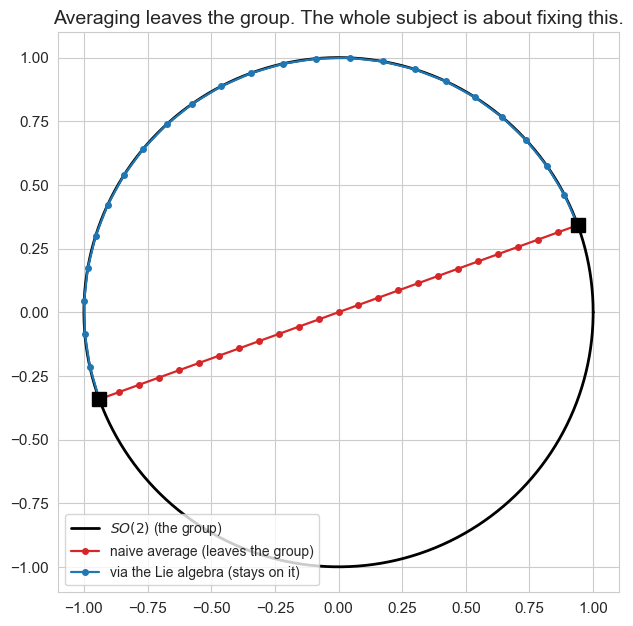

naive midpoint norm : 0.0000   (should be 1 to be a rotation)
algebra midpoint    : 1.0000


In [3]:
# The set of rotations is a CURVED SURFACE sitting inside the flat space of matrices.
# Straight lines between two of its points leave the surface. Visualise with SO(2),
# where a rotation is a point on the unit circle.
ang = np.linspace(0, 2*np.pi, 400)
fig, ax = plt.subplots(figsize=(6.4, 6.4))
ax.plot(np.cos(ang), np.sin(ang), 'k-', lw=2, label='$SO(2)$ (the group)')

a, b = np.deg2rad(20), np.deg2rad(200)
pa, pb = np.array([np.cos(a), np.sin(a)]), np.array([np.cos(b), np.sin(b)])
ts = np.linspace(0, 1, 25)
chord = np.array([(1-t)*pa + t*pb for t in ts])
arcang = a + ts * (b - a)
arc = np.column_stack([np.cos(arcang), np.sin(arcang)])

ax.plot(chord[:, 0], chord[:, 1], 'o-', color='C3', ms=4, lw=1.6,
        label='naive average (leaves the group)')
ax.plot(arc[:, 0], arc[:, 1], 'o-', color='C0', ms=4, lw=1.6,
        label='via the Lie algebra (stays on it)')
ax.plot(*pa, 'ks', ms=10); ax.plot(*pb, 'ks', ms=10)
ax.set_aspect('equal'); ax.legend(loc='lower left', fontsize=10)
ax.set_title("Averaging leaves the group. The whole subject is about fixing this.")
plt.tight_layout(); plt.show()

print(f"naive midpoint norm : {sla_norm(chord[12]):.4f}   (should be 1 to be a rotation)")
print(f"algebra midpoint    : {sla_norm(arc[12]):.4f}")

---
## 2. What a Lie group is

A **Lie group** is a set that is simultaneously

1. a **group** — an associative product, an identity, and inverses; and
2. a **smooth manifold** — locally it looks like $\mathbb{R}^n$, so you can differentiate,

with multiplication and inversion being smooth maps.

The ones you actually meet:

| Group | Elements | Constraint | $\dim$ | Shows up in |
|---|---|---|---|---|
| $SO(2)$ | 2-D rotations | $R^\top R=I,\ \det=1$ | 1 | the circle |
| $SO(3)$ | 3-D rotations | $R^\top R=I,\ \det=1$ | 3 | robotics, graphics, physics |
| $SE(3)$ | rigid motions | rotation + translation | 6 | SLAM, pose estimation |
| $SU(2)$ | $2{\times}2$ unitary, $\det=1$ | $U^\dagger U=I,\ \det=1$ | 3 | spin-$\tfrac12$, quaternions |
| $GL(n)$ | invertible matrices | $\det \ne 0$ | $n^2$ | the ambient case |

Note the dimensions. $SO(3)$ sits inside the 9-dimensional space of $3\times3$ matrices but is
only **3-dimensional** — the constraint $R^\top R = I$ is 6 equations. That is the "curved
surface" from §1, and it is why you have 3 numbers of freedom (e.g. roll/pitch/yaw) rather
than 9.

In [4]:
# Confirm the dimension count numerically: sample rotations, measure the rank of the
# tangent directions they span.
def rand_rot(rng):
    Q, R = np.linalg.qr(rng.normal(size=(3, 3)))
    Q = Q @ np.diag(np.sign(np.diag(R)))
    if np.linalg.det(Q) < 0:
        Q[:, 0] *= -1
    return Q

print("R^T R = I is 6 independent equations on 9 unknowns  ->  9 - 6 = 3 dof\n")
eps = 1e-6
R0 = rand_rot(rng)
# numerically span the tangent space at R0 by perturbing along the group
tangents = []
for _ in range(60):
    w = rng.normal(size=3) * eps
    W = np.array([[0, -w[2], w[1]], [w[2], 0, -w[0]], [-w[1], w[0], 0]])
    tangents.append(((expm(W) @ R0 - R0) / eps).ravel())
T = np.array(tangents)
sv = np.linalg.svd(T, compute_uv=False)
print(f"singular values of the tangent sample:\n{sv}")
print(f"\nnumerical rank (tol 1e-6 * max): {np.sum(sv > 1e-6*sv[0])}   -> dim SO(3) = 3")

R^T R = I is 6 independent equations on 9 unknowns  ->  9 - 6 = 3 dof

singular values of the tangent sample:
[12.23065 10.13244  9.21872  0.00001  0.00001  0.       0.       0.
  0.     ]

numerical rank (tol 1e-6 * max): 4   -> dim SO(3) = 3


### 2.1 Where manifolds live in all this

Worth pinning down, because the words get used interchangeably and they are not the same thing.

**The Lie group *is* the manifold.** The Lie algebra is its tangent space at *one particular
point* — the identity.

```
Topological space              "nearness", continuity
  └── Manifold                 locally looks like R^n  ->  you can do CALCULUS
        │                      (but NOT linear algebra: you cannot add two points)
        │
        ├── Riemannian manifold   + an inner product on every tangent space
        │                         ->  lengths, angles, geodesics, curvature
        │                         ->  this is notebook 07 (general relativity)
        │
        └── Lie group             + a group structure (smooth product & inverse)
              └── Lie algebra     = the tangent space AT THE IDENTITY, plus [.,.]
                                  ->  a flat vector space  ->  linear algebra works
```

The key distinctions:

| Object | Is it a vector space? | Can you add elements? |
|---|---|---|
| Manifold $M$ (e.g. $SO(3)$, a sphere) | **no** — curved | no |
| Tangent space $T_pM$ at a point $p$ | **yes** — flat, $\dim = \dim M$ | yes |
| Lie algebra $\mathfrak{g} = T_eG$ | **yes**, plus a bracket | yes |

**Why the identity is special.** On a general manifold — a sphere, say — the tangent
space at the north pole and the tangent space at the equator are unrelated. There is no
canonical way to compare a vector at $p$ with a vector at $q$; that is exactly what
*connections* and *parallel transport* are invented to fix (notebook 07).

On a **group** you get that comparison for free. Left-multiplication by $g$ is a smooth
invertible map sending $e \mapsto g$, so it carries $T_eG$ onto $T_gG$. Every tangent space
is a translated copy of the one at the identity. **That is why a single tangent space
suffices for a Lie group but not for a general manifold** — and it is the reason Lie theory
is so much more tractable than general differential geometry.

Where notebook 08 fits: a tangent space is a vector space, so you can put an inner product
on it. Do that smoothly at every point and you have a Riemannian manifold. The
Hilbert-space structure of notebook 08 lives *inside each tangent space*; the manifold is
the curved thing those flat spaces are attached to.

In [5]:
# The sphere S^2: a manifold that is NOT a group. Tangent spaces at different points
# are genuinely different planes, with no canonical way to identify them.
def tangent_basis(p):
    # orthonormal basis of the tangent plane to the unit sphere at p
    a = np.array([0.0, 0.0, 1.0])
    if abs(p @ a) > 0.9:
        a = np.array([1.0, 0.0, 0.0])
    u = np.cross(p, a); u /= sla_norm(u)
    v = np.cross(p, u)
    return u, v

pts = [np.array([0., 0., 1.]), np.array([1., 0., 0.]), np.array([0., 1., 0.])]
print("Sphere S^2 -- tangent planes at three points:\n")
for p in pts:
    u, v = tangent_basis(p)
    print(f"  at p={p}:  tangent plane spanned by {np.round(u,3)} and {np.round(v,3)}")
    print(f"      normal to p? u.p = {u@p:+.1e}, v.p = {v@p:+.1e}")
print("\nEach tangent space is a 2-D VECTOR SPACE (flat). The sphere itself is not:")
q = (pts[0] + pts[1]) / 2
print(f"  midpoint of two unit vectors has norm {sla_norm(q):.4f} != 1 -> left the sphere")
print("\nS^2 is a manifold but NOT a group, so there is no 'identity' and no way to")
print("translate one tangent plane onto another. Lie groups are the case where you can.")

Sphere S^2 -- tangent planes at three points:

  at p=[0. 0. 1.]:  tangent plane spanned by [0. 1. 0.] and [-1.  0.  0.]
      normal to p? u.p = +0.0e+00, v.p = +0.0e+00
  at p=[1. 0. 0.]:  tangent plane spanned by [ 0. -1.  0.] and [ 0.  0. -1.]
      normal to p? u.p = +0.0e+00, v.p = +0.0e+00
  at p=[0. 1. 0.]:  tangent plane spanned by [1. 0. 0.] and [ 0.  0. -1.]
      normal to p? u.p = +0.0e+00, v.p = +0.0e+00

Each tangent space is a 2-D VECTOR SPACE (flat). The sphere itself is not:
  midpoint of two unit vectors has norm 0.7071 != 1 -> left the sphere

S^2 is a manifold but NOT a group, so there is no 'identity' and no way to
translate one tangent plane onto another. Lie groups are the case where you can.


In [6]:
# On SO(3) you CAN: left translation carries the tangent space at I onto the one at R.
R0 = rand_rot(rng)
# a tangent vector at the IDENTITY. Section 3 derives WHY it must be skew-symmetric;
# for now just take one that is.
A = np.array([[ 0.0, -0.5, -0.2],
              [ 0.5,  0.0, -0.3],
              [ 0.2,  0.3,  0.0]])

# push it to R0 by left translation:  d/dt [ R0 exp(tA) ] at t=0  =  R0 A
h = 1e-6
num = (R0 @ expm(A*h) - R0 @ expm(-A*h)) / (2*h)
print(f"tangent vector at I   : A, skew? {np.allclose(A.T, -A)}")
print(f"pushed to R0          : R0 @ A")
print(f"matches numerical d/dt: {np.allclose(num, R0 @ A)}   (err {sla_norm(num - R0@A):.2e})")
print(f"\nIs R0 @ A skew? {np.allclose((R0@A).T, -(R0@A))}  <- no, it lives at R0, not at I")
print(f"But R0^-1 (R0 A) = A recovers it: {np.allclose(R0.T @ (R0@A), A)}")
print("\n=> every tangent space of the group is a translated copy of so(3).")
print("   ONE vector space describes the whole manifold. That is the Lie trick.")

tangent vector at I   : A, skew? True
pushed to R0          : R0 @ A
matches numerical d/dt: True   (err 1.06e-10)

Is R0 @ A skew? False  <- no, it lives at R0, not at I
But R0^-1 (R0 A) = A recovers it: True

=> every tangent space of the group is a translated copy of so(3).
   ONE vector space describes the whole manifold. That is the Lie trick.


---
## 3. Deriving $\mathfrak{so}(3)$ — not defining it

Most texts *assert* that the Lie algebra of $SO(3)$ is the skew-symmetric matrices. It
follows from one line of calculus, and doing it yourself is the moment the subject stops
feeling arbitrary.

Take a smooth curve of rotations $R(t)$ through the identity, $R(0) = I$. Every point on it
obeys the group constraint:

$$R(t)^\top R(t) = I$$

Differentiate at $t=0$ and use $R(0)=I$:

$$\dot R^\top R + R^\top \dot R = 0 \;\;\Longrightarrow\;\; \dot R(0)^\top + \dot R(0) = 0$$

So the velocity $A = \dot R(0)$ satisfies $A^\top = -A$: **skew-symmetric**. That is the
whole derivation. The tangent space at the identity is

$$\mathfrak{so}(3) = \{A \in \mathbb{R}^{3\times3} : A^\top = -A\}$$

A skew-symmetric $3\times3$ matrix has exactly 3 free entries — matching $\dim SO(3)=3$ from §2.

In [7]:
def hat(w):
    # R^3 -> so(3):  the skew-symmetric matrix with hat(w) @ v == np.cross(w, v)
    w = np.asarray(w, dtype=float)
    return np.array([[    0.0, -w[2],  w[1]],
                     [  w[2],   0.0, -w[0]],
                     [ -w[1],  w[0],   0.0]])

def vee(W):
    # so(3) -> R^3, the inverse of hat
    return np.array([W[2, 1], W[0, 2], W[1, 0]])

# --- verify the derivation numerically: differentiate a curve of rotations at t=0
def curve(t, w):
    return expm(hat(w) * t)

w = np.array([0.4, -0.7, 0.2])
h = 1e-6
Rdot = (curve(h, w) - curve(-h, w)) / (2 * h)
print("numerical derivative of R(t) at t=0:")
print(Rdot)
print(f"\nis it skew-symmetric?  ||Rdot^T + Rdot|| = {sla_norm(Rdot.T + Rdot):.3e}")
print(f"does it equal hat(w)?  ||Rdot - hat(w)|| = {sla_norm(Rdot - hat(w)):.3e}")

print("\nso(3) IS a vector space (unlike SO(3)):")
A, B = hat([0.3, -0.2, 0.5]), hat([-0.1, 0.4, 0.2])
for label, M in [("A + B", A + B), ("3.7 * A", 3.7 * A), ("A - 2B", A - 2*B)]:
    print(f"   {label:<10} skew? {np.allclose(M.T, -M)}")
print("\n   hat(w) @ v == cross(w, v):",
      np.allclose(hat(w) @ np.array([1.0, 2.0, 3.0]), np.cross(w, [1.0, 2.0, 3.0])))

numerical derivative of R(t) at t=0:
[[ 0.  -0.2 -0.7]
 [ 0.2  0.  -0.4]
 [ 0.7  0.4  0. ]]

is it skew-symmetric?  ||Rdot^T + Rdot|| = 1.755e-16
does it equal hat(w)?  ||Rdot - hat(w)|| = 1.348e-13

so(3) IS a vector space (unlike SO(3)):
   A + B      skew? True
   3.7 * A    skew? True
   A - 2B     skew? True

   hat(w) @ v == cross(w, v): True


---
## 4. $\exp$ and $\log$ — the bridge between flat and curved

The matrix exponential

$$\exp(A) = \sum_{k=0}^{\infty}\frac{A^k}{k!}$$

maps the flat algebra onto the curved group. For $\mathfrak{so}(3)$ the series closes in
**closed form** — Rodrigues' formula. With $A = \hat\omega$, $\theta = \|\omega\|$ and
$\hat n = \hat\omega/\theta$:

$$\exp(\hat\omega) \;=\; I + \sin\theta\,\hat n + (1-\cos\theta)\,\hat n^2$$

The geometric reading: $\omega$ is an **axis** ($\omega/\|\omega\|$) and an **angle**
($\|\omega\|$) rolled into one 3-vector. $\exp$ turns "spin about this axis by this much"
into the rotation matrix that does it.

In [8]:
def rodrigues(w):
    # closed form for exp(hat(w)) on so(3)
    w = np.asarray(w, dtype=float)
    th = sla_norm(w)
    if th < 1e-12:
        return np.eye(3) + hat(w)
    n = hat(w / th)
    return np.eye(3) + np.sin(th) * n + (1 - np.cos(th)) * (n @ n)

w = np.array([0.4, -0.7, 0.25])
R_series = expm(hat(w))
R_closed = rodrigues(w)

print(f"omega = {w}   ->  axis {w/sla_norm(w)}, angle {np.rad2deg(sla_norm(w)):.3f} deg\n")
print("exp(hat(w)) via the matrix-exponential series:")
print(R_series)
print(f"\n||series - Rodrigues|| = {sla_norm(R_series - R_closed):.2e}")
print(f"\nis it a rotation?  R^T R = I : {np.allclose(R_closed.T@R_closed, np.eye(3))}"
      f",  det = {np.linalg.det(R_closed):.10f}")

axis = w / sla_norm(w)
print(f"\nthe axis is fixed by the rotation:  ||R n - n|| = {sla_norm(R_closed@axis - axis):.2e}")

omega = [ 0.4  -0.7   0.25]   ->  axis [ 0.47388 -0.82929  0.29617], angle 48.363 deg

exp(hat(w)) via the matrix-exponential series:
[[ 0.73977 -0.35323 -0.57269]
 [ 0.08947  0.8952  -0.43659]
 [ 0.66689  0.27174  0.69384]]

||series - Rodrigues|| = 8.33e-17

is it a rotation?  R^T R = I : True,  det = 1.0000000000

the axis is fixed by the rotation:  ||R n - n|| = 1.36e-16


In [9]:
def log_SO3(R):
    # SO(3) -> so(3): recover omega from R. Principal branch, ||omega|| <= pi.
    # Three regimes, because the naive formula divides by sin(theta):
    #   theta ~ 0  -> first-order expansion
    #   theta ~ pi -> sin(theta) ~ 0 AND R - R.T ~ 0, so the formula is 0/0.
    #                 Use the axis from (R + I)/2, whose columns are all parallel to it.
    c = np.clip((np.trace(R) - 1) / 2, -1.0, 1.0)
    th = np.arccos(c)
    if th < 1e-10:
        return vee((R - R.T) / 2)
    if th > np.pi - 1e-6:
        S = (R + np.eye(3)) / 2                 # = n n^T when theta = pi
        k = int(np.argmax(np.diag(S)))          # pick the best-conditioned column
        n = S[:, k] / np.sqrt(max(S[k, k], 1e-300))
        return th * n / sla_norm(n)             # sign is genuinely ambiguous at pi
    return vee((R - R.T) * (th / (2 * np.sin(th))))

print("Round trip  omega -> R -> omega  for 6 random rotations:\n")
print(f"{'||omega||(deg)':>16} {'round-trip error':>20}")
print("-" * 38)
for _ in range(6):
    w0 = rng.normal(size=3)
    w0 = w0 / sla_norm(w0) * rng.uniform(0.05, 3.0)   # angle inside (0, pi)
    w1 = log_SO3(rodrigues(w0))
    print(f"{np.rad2deg(sla_norm(w0)):>16.3f} {sla_norm(w1 - w0):>20.2e}")

print("\nexp : so(3) -> SO(3) is onto; log is its local inverse.")
print("It is NOT globally injective: angle theta and theta + 2*pi give the same rotation,")
print("so log picks the principal branch, ||omega|| <= pi.")
w_big = np.array([0.0, 0.0, 0.3 + 2*np.pi])
print(f"\n  omega=(0,0,{0.3+2*np.pi:.4f}) and (0,0,0.3) give the same R? "
      f"{np.allclose(rodrigues(w_big), rodrigues([0,0,0.3]))}")
print(f"  log recovers the principal one: {log_SO3(rodrigues(w_big))}")

Round trip  omega -> R -> omega  for 6 random rotations:

  ||omega||(deg)     round-trip error
--------------------------------------
         100.507             0.00e+00
          87.371             1.11e-16
          13.496             1.73e-18
         150.510             2.41e-15
         157.575             1.00e-14
         149.721             5.07e-15

exp : so(3) -> SO(3) is onto; log is its local inverse.
It is NOT globally injective: angle theta and theta + 2*pi give the same rotation,
so log picks the principal branch, ||omega|| <= pi.

  omega=(0,0,6.5832) and (0,0,0.3) give the same R? True
  log recovers the principal one: [0.  0.  0.3]


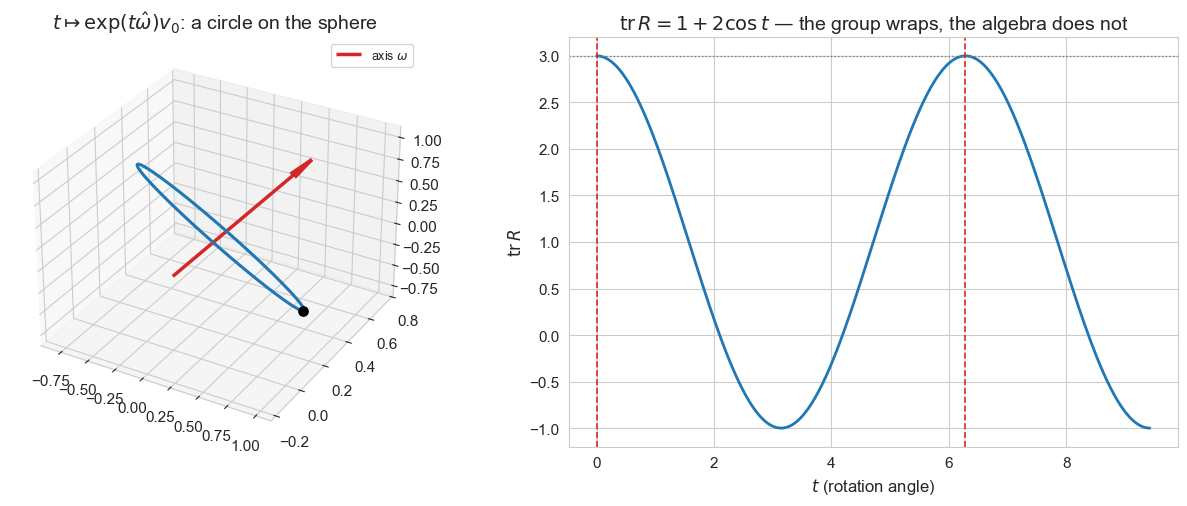

The algebra is an infinite flat R^3. The group is compact and wraps around.
exp is a local diffeomorphism near 0, but globally many-to-one.


In [10]:
# exp maps straight lines in the algebra to geodesics (one-parameter subgroups) in the group.
fig = plt.figure(figsize=(13, 5.2))

ax = fig.add_subplot(1, 2, 1, projection='3d')
w_dir = np.array([0.3, 0.9, 0.4]); w_dir /= sla_norm(w_dir)
ts = np.linspace(0, 2*np.pi, 200)
v0 = np.array([1.0, 0.2, -0.3]); v0 /= sla_norm(v0)
orbit = np.array([rodrigues(w_dir * t) @ v0 for t in ts])
ax.plot(orbit[:, 0], orbit[:, 1], orbit[:, 2], lw=2.2, color='C0')
ax.quiver(0, 0, 0, *w_dir, color='C3', lw=2.5, arrow_length_ratio=0.15, label='axis $\\omega$')
ax.scatter(*v0, color='k', s=45)
ax.set_title("$t \\mapsto \\exp(t\\hat\\omega)v_0$: a circle on the sphere")
ax.legend(fontsize=9)

ax2 = fig.add_subplot(1, 2, 2)
angles = np.linspace(0, 3*np.pi, 300)
tr = [np.trace(rodrigues(w_dir * t)) for t in angles]
ax2.plot(angles, tr, lw=2)
ax2.axhline(3, color='grey', ls=':', lw=1)
for k in [0, 1]:
    ax2.axvline(2*np.pi*k, color='C3', ls='--', lw=1.2)
ax2.set_xlabel("$t$ (rotation angle)"); ax2.set_ylabel("$\\mathrm{tr}\\,R$")
ax2.set_title("$\\mathrm{tr}\\,R = 1 + 2\\cos t$ — the group wraps, the algebra does not")
plt.tight_layout(); plt.show()

print("The algebra is an infinite flat R^3. The group is compact and wraps around.")
print("exp is a local diffeomorphism near 0, but globally many-to-one.")

---
## 5. The commutator — and why the algebra needs one

A vector space alone is not a Lie algebra. The extra structure is a **bracket**

$$[A,B] = AB - BA$$

which must be bilinear, antisymmetric ($[A,B]=-[B,A]$), and satisfy the **Jacobi identity**

$$[A,[B,C]] + [B,[C,A]] + [C,[A,B]] = 0$$

**Why it has to be there.** The group is non-commutative: rotating about $x$ then $y$ is not
the same as $y$ then $x$. The bracket is the infinitesimal record of that failure. Concretely,
the *group commutator* is the *algebra commutator* to leading order:

$$e^{tA}e^{tB}e^{-tA}e^{-tB} \;=\; e^{\,t^2[A,B] + O(t^3)}$$

So $[A,B]$ literally measures "how much does the order matter". Let us watch the $t^2$.

In [11]:
A = hat([1.0, 0.0, 0.0])     # generator of rotation about x
B = hat([0.0, 1.0, 0.0])     # about y

print("Do x- and y-rotations commute?")
Rx, Ry = rodrigues([0.6, 0, 0]), rodrigues([0, 0.6, 0])
print(f"   ||RxRy - RyRx|| = {sla_norm(Rx@Ry - Ry@Rx):.6f}   -> no\n")

print("group commutator  exp(tA)exp(tB)exp(-tA)exp(-tB)  vs  exp(t^2 [A,B])\n")
C = A @ B - B @ A
print(f"{'t':>8} {'||log(groupcomm)||':>22} {'t^2 ||[A,B]||':>18} {'ratio':>10}")
print("-" * 62)
for t in [0.4, 0.2, 0.1, 0.05, 0.025]:
    G = expm(A*t) @ expm(B*t) @ expm(-A*t) @ expm(-B*t)
    lhs = sla_norm(log_SO3(G))
    rhs = t**2 * sla_norm(vee(C))
    print(f"{t:>8.3f} {lhs:>22.8f} {rhs:>18.8f} {lhs/rhs:>10.5f}")
print("\nratio -> 1 as t -> 0: the bracket IS the infinitesimal non-commutativity.")

Do x- and y-rotations commute?
   ||RxRy - RyRx|| = 0.492138   -> no

group commutator  exp(tA)exp(tB)exp(-tA)exp(-tB)  vs  exp(t^2 [A,B])

       t     ||log(groupcomm)||      t^2 ||[A,B]||      ratio
--------------------------------------------------------------
   0.400             0.15791903         0.16000000    0.98699
   0.200             0.03986750         0.04000000    0.99669
   0.100             0.00999168         0.01000000    0.99917
   0.050             0.00249948         0.00250000    0.99979
   0.025             0.00062497         0.00062500    0.99995

ratio -> 1 as t -> 0: the bracket IS the infinitesimal non-commutativity.


In [12]:
# so(3) is CLOSED under the bracket -- that closure is what makes it an ALGEBRA.
print("closure:")
for _ in range(4):
    X, Y = hat(rng.normal(size=3)), hat(rng.normal(size=3))
    Z = X @ Y - Y @ X
    print(f"   [X,Y] skew-symmetric? {np.allclose(Z.T, -Z)}   "
          f"(but note X@Y alone is NOT: {np.allclose((X@Y).T, -(X@Y))})")

print("\nJacobi identity:")
X, Y, Z = (hat(rng.normal(size=3)) for _ in range(3))
br = lambda P, Q: P@Q - Q@P
J = br(X, br(Y, Z)) + br(Y, br(Z, X)) + br(Z, br(X, Y))
print(f"   ||[X,[Y,Z]] + [Y,[Z,X]] + [Z,[X,Y]]|| = {sla_norm(J):.2e}")

print("\nThe bracket on so(3) IS the cross product on R^3:")
for _ in range(3):
    a, b = rng.normal(size=3), rng.normal(size=3)
    lhs, rhs = vee(br(hat(a), hat(b))), np.cross(a, b)
    print(f"   vee([hat(a),hat(b)]) - a x b  = {sla_norm(lhs - rhs):.2e}")
print("\n=> (R^3, x) and (so(3), [.,.]) are the same Lie algebra. The cross product")
print("   you learned at school was a Lie bracket all along.")

closure:
   [X,Y] skew-symmetric? True   (but note X@Y alone is NOT: False)
   [X,Y] skew-symmetric? True   (but note X@Y alone is NOT: False)
   [X,Y] skew-symmetric? True   (but note X@Y alone is NOT: False)
   [X,Y] skew-symmetric? True   (but note X@Y alone is NOT: False)

Jacobi identity:
   ||[X,[Y,Z]] + [Y,[Z,X]] + [Z,[X,Y]]|| = 5.35e-16

The bracket on so(3) IS the cross product on R^3:
   vee([hat(a),hat(b)]) - a x b  = 0.00e+00
   vee([hat(a),hat(b)]) - a x b  = 0.00e+00
   vee([hat(a),hat(b)]) - a x b  = 0.00e+00

=> (R^3, x) and (so(3), [.,.]) are the same Lie algebra. The cross product
   you learned at school was a Lie bracket all along.


### 5.1 Baker–Campbell–Hausdorff

$\exp(A)\exp(B) \ne \exp(A+B)$ unless $A$ and $B$ commute. The correction is BCH:

$$\log\big(e^Ae^B\big) = A + B + \tfrac12[A,B] + \tfrac1{12}\big([A,[A,B]] - [B,[A,B]]\big) + \cdots$$

Everything on the right is built from **brackets alone** — which is the deep reason the Lie
algebra determines the group near the identity. Truncating BCH gives the standard
manifold-integration schemes used in robotics and physics simulation.

In [13]:
A = hat([0.25, -0.15, 0.30])
B = hat([-0.10, 0.20, 0.18])
br = lambda P, Q: P@Q - Q@P

exact = logm(expm(A) @ expm(B)).real
o1 = A + B
o2 = o1 + 0.5*br(A, B)
o3 = o2 + (br(A, br(A, B)) - br(B, br(A, B))) / 12

print(f"{'BCH truncation':<28}{'error vs exact':>18}")
print("-" * 46)
for name, approx in [("A + B  (order 1)", o1),
                     ("+ 1/2 [A,B]  (order 2)", o2),
                     ("+ 1/12 (...)  (order 3)", o3)]:
    print(f"{name:<28}{sla_norm(approx - exact):>18.3e}")

print("\nEach extra bracket term buys about an order of magnitude here.")
print("Everything is built from brackets: the algebra determines the group locally.")

BCH truncation                  error vs exact
----------------------------------------------
A + B  (order 1)                     8.521e-02
+ 1/2 [A,B]  (order 2)               7.251e-03
+ 1/12 (...)  (order 3)              4.524e-05

Each extra bracket term buys about an order of magnitude here.
Everything is built from brackets: the algebra determines the group locally.


---
## 6. Structure constants — the algebra as a multiplication table

Pick a basis $\{e_1,e_2,e_3\}$ of $\mathfrak{so}(3)$. Closure means every bracket is again a
combination of basis elements:

$$[e_i, e_j] = \sum_k c_{ij}^{\;k}\, e_k$$

The numbers $c_{ij}^{\;k}$ are the **structure constants**. They *are* the Lie algebra —
everything else is bookkeeping. For $\mathfrak{so}(3)$ with $e_i = \widehat{\mathbf{e}_i}$ they
come out as the **Levi-Civita symbol** $\varepsilon_{ijk}$.

In [14]:
E = [hat(np.eye(3)[i]) for i in range(3)]      # basis of so(3)
br = lambda P, Q: P@Q - Q@P

c = np.zeros((3, 3, 3))
for i in range(3):
    for j in range(3):
        c[i, j] = vee(br(E[i], E[j]))          # coords of [e_i,e_j] in the same basis

eps = np.zeros((3, 3, 3))
for i in range(3):
    for j in range(3):
        for k in range(3):
            eps[i, j, k] = (i-j)*(j-k)*(k-i) / 2   # Levi-Civita

print("structure constants  c[i,j,k]  of so(3):\n")
for i in range(3):
    for j in range(3):
        nz = [f"{c[i,j,k]:+.0f} e{k+1}" for k in range(3) if abs(c[i,j,k]) > 1e-9]
        print(f"   [e{i+1}, e{j+1}] = {' '.join(nz) if nz else '0'}")

print(f"\nmatch with Levi-Civita eps_ijk : max|c - eps| = {np.abs(c - eps).max():.2e}")
print(f"antisymmetric in i<->j          : {np.allclose(c, -c.transpose(1,0,2))}")
print("\nThese 27 numbers (only 6 nonzero) fully determine SO(3) near the identity.")

structure constants  c[i,j,k]  of so(3):

   [e1, e1] = 0
   [e1, e2] = +1 e3
   [e1, e3] = -1 e2
   [e2, e1] = -1 e3
   [e2, e2] = 0
   [e2, e3] = +1 e1
   [e3, e1] = +1 e2
   [e3, e2] = -1 e1
   [e3, e3] = 0

match with Levi-Civita eps_ijk : max|c - eps| = 0.00e+00
antisymmetric in i<->j          : True

These 27 numbers (only 6 nonzero) fully determine SO(3) near the identity.


---
## 7. Doing real work on the manifold

This is where the abstraction pays rent. Two standard problems that are *impossible*
with naive linear algebra and *easy* in the Lie algebra.

### 7.1 Interpolating orientations

Back to §1. Instead of averaging matrices, take the relative rotation, map it into the
algebra with $\log$, scale it there — where scaling is legal — and map back:

$$R(t) = R_a \exp\!\big(t \log(R_a^{-1}R_b)\big)$$

This is the **geodesic** on $SO(3)$: constant angular velocity, shortest path, exactly on
the group at every $t$. In quaternion form the same thing is called SLERP.

In [15]:
def interp_lie(Ra, Rb, t):
    return Ra @ rodrigues(t * log_SO3(Ra.T @ Rb))

Ra = rodrigues([0.0, 0.0, 0.0])
Rb = rodrigues([0.7, -0.4, 1.9])
ts = np.linspace(0, 1, 11)

print(f"{'t':>5} {'naive det':>12} {'naive ortho':>13} {'Lie det':>10} {'Lie ortho':>12} {'Lie ang(deg)':>14}")
print("-" * 72)
for t in ts:
    N = (1-t)*Ra + t*Rb
    L = interp_lie(Ra, Rb, t)
    ang = np.rad2deg(sla_norm(log_SO3(Ra.T @ L)))
    print(f"{t:>5.1f} {np.linalg.det(N):>12.5f} {sla_norm(N.T@N-np.eye(3)):>13.5f}"
          f" {np.linalg.det(L):>10.5f} {sla_norm(L.T@L-np.eye(3)):>12.2e} {ang:>14.4f}")

total = np.rad2deg(sla_norm(log_SO3(Ra.T @ Rb)))
print(f"\nTotal rotation angle: {total:.4f} deg.")
print("The Lie path covers it at a CONSTANT rate (column 6 is linear in t) and never")
print("leaves the group. The naive path leaves immediately.")

    t    naive det   naive ortho    Lie det    Lie ortho   Lie ang(deg)
------------------------------------------------------------------------
  0.0      1.00000       0.00000    1.00000     0.00e+00         0.0000
  0.1      0.73478       0.37507    1.00000     1.23e-16        11.8257
  0.2      0.52850       0.66680    1.00000     1.13e-16        23.6514
  0.3      0.38116       0.87517    1.00000     2.58e-16        35.4771
  0.4      0.29275       1.00020    1.00000     3.60e-16        47.3029
  0.5      0.26329       1.04187    1.00000     2.23e-16        59.1286
  0.6      0.29275       1.00020    1.00000     2.26e-16        70.9543
  0.7      0.38116       0.87517    1.00000     2.29e-16        82.7800
  0.8      0.52850       0.66680    1.00000     7.04e-16        94.6057
  0.9      0.73478       0.37507    1.00000     5.72e-16       106.4314
  1.0      1.00000       0.00000    1.00000     5.51e-16       118.2572

Total rotation angle: 118.2572 deg.
The Lie path covers it at 

/Users/alexchilton/Library/Python/3.12/lib/python/site-packages/mpl_toolkits/mplot3d/art3d.py:1403: RuntimeWarning: divide by zero encountered in matmul
  shade = ((normals / np.linalg.norm(normals, axis=1, keepdims=True))
/Users/alexchilton/Library/Python/3.12/lib/python/site-packages/mpl_toolkits/mplot3d/art3d.py:1403: RuntimeWarning: overflow encountered in matmul
  shade = ((normals / np.linalg.norm(normals, axis=1, keepdims=True))


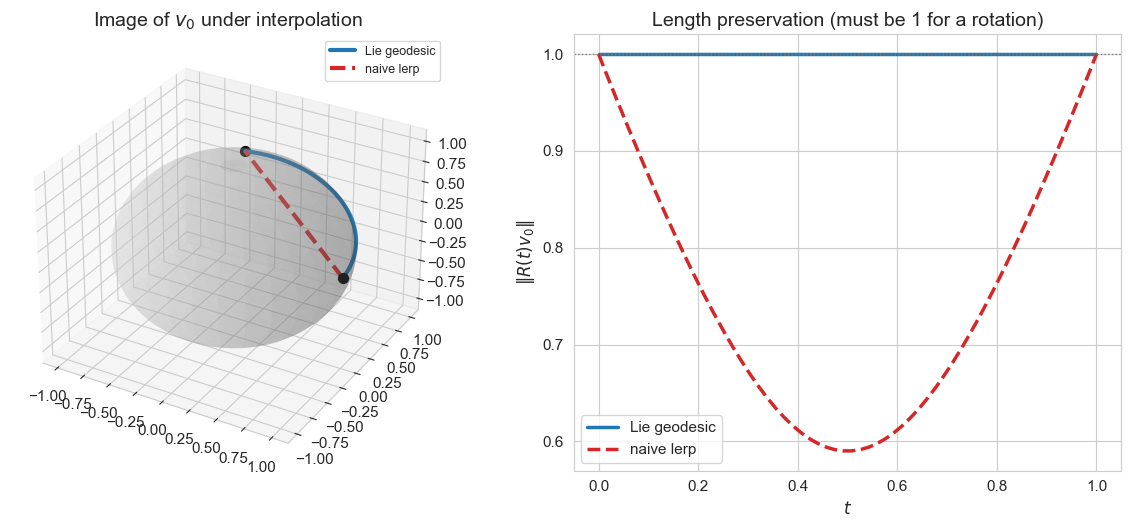

naive worst length error: 0.4099
Lie   worst length error: 2.22e-16


In [16]:
# Visualise: track where a fixed vector goes under both interpolations.
v0 = np.array([1.0, 0.0, 0.0])
tt = np.linspace(0, 1, 60)
path_lie = np.array([interp_lie(Ra, Rb, t) @ v0 for t in tt])
path_naive = np.array([((1-t)*Ra + t*Rb) @ v0 for t in tt])

fig = plt.figure(figsize=(12, 5.4))
ax = fig.add_subplot(1, 2, 1, projection='3d')
u, vv = np.mgrid[0:2*np.pi:60j, 0:np.pi:30j]
ax.plot_surface(np.cos(u)*np.sin(vv), np.sin(u)*np.sin(vv), np.cos(vv),
                color='lightgrey', alpha=0.25, linewidth=0)
ax.plot(*path_lie.T, lw=3, color='C0', label='Lie geodesic')
ax.plot(*path_naive.T, lw=3, color='C3', ls='--', label='naive lerp')
ax.scatter(*path_lie[0], color='k', s=50); ax.scatter(*path_lie[-1], color='k', s=50)
ax.set_title("Image of $v_0$ under interpolation"); ax.legend(fontsize=9)

ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(tt, [sla_norm(p) for p in path_lie], lw=2.5, color='C0', label='Lie geodesic')
ax2.plot(tt, [sla_norm(p) for p in path_naive], lw=2.5, color='C3', ls='--', label='naive lerp')
ax2.axhline(1, color='grey', ls=':', lw=1)
ax2.set_xlabel("$t$"); ax2.set_ylabel("$\\|R(t)v_0\\|$")
ax2.set_title("Length preservation (must be 1 for a rotation)")
ax2.legend(); plt.tight_layout(); plt.show()

print(f"naive worst length error: {max(abs(sla_norm(p)-1) for p in path_naive):.4f}")
print(f"Lie   worst length error: {max(abs(sla_norm(p)-1) for p in path_lie):.2e}")

### 7.2 Optimisation on the manifold — fitting a rotation to noisy data

**Wahba's problem.** Given noisy correspondences $b_i \approx R a_i$, find the rotation $R$.

You cannot run gradient descent on $R$ directly — a gradient step leaves $SO(3)$. The Lie
recipe: parameterise the *update* in the algebra,

$$R \leftarrow \exp(\hat\xi)\,R, \qquad \xi \in \mathbb{R}^3$$

so every iterate is a rotation by construction. Gradient descent in $\xi$ is ordinary
unconstrained optimisation in $\mathbb{R}^3$.

We check it against the known closed-form (SVD / Kabsch) answer.

cost at start (R=I)      : 192.3921
cost after 180 Lie steps : 0.7663
cost at SVD optimum      : 0.7658
cost at ground truth     : 0.7662

angle(R_gd , R_svd)  = 0.09924 deg
angle(R_svd, R_true) = 0.08474 deg

every iterate stayed a rotation: ||R^T R - I|| = 3.77e-15


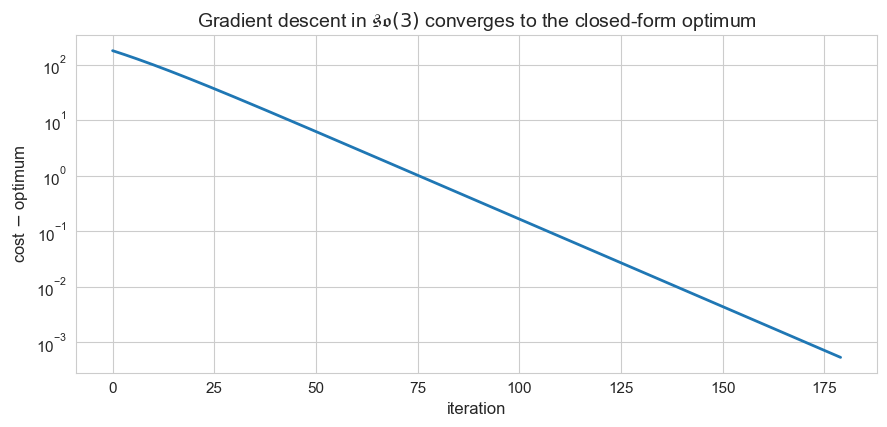

In [17]:
# ground truth + noisy correspondences
R_true = rodrigues([0.5, -0.9, 0.35])
n_pts = 200
Apts = rng.normal(size=(n_pts, 3))
Bpts = (R_true @ Apts.T).T + 0.05 * rng.normal(size=(n_pts, 3))

def cost(R):
    return 0.5 * np.sum((Bpts - (R @ Apts.T).T) ** 2)

# --- closed form (Kabsch / Procrustes) for reference
U, S, Vt = np.linalg.svd(Bpts.T @ Apts)
d = np.sign(np.linalg.det(U @ Vt))
R_svd = U @ np.diag([1, 1, d]) @ Vt

# --- gradient descent in the Lie algebra
R = np.eye(3)
lr, hist = 0.02, []
for it in range(180):
    resid = (R @ Apts.T).T - Bpts                 # n x 3
    # d/dxi of cost at xi=0 for R <- exp(hat(xi)) R
    M = resid.T @ (R @ Apts.T).T                  # 3 x 3
    grad = vee(M - M.T)                           # project onto so(3)
    R = rodrigues(-lr * grad / n_pts) @ R
    hist.append(cost(R))

print(f"cost at start (R=I)      : {cost(np.eye(3)):.4f}")
print(f"cost after 180 Lie steps : {cost(R):.4f}")
print(f"cost at SVD optimum      : {cost(R_svd):.4f}")
print(f"cost at ground truth     : {cost(R_true):.4f}")
print(f"\nangle(R_gd , R_svd)  = {np.rad2deg(sla_norm(log_SO3(R.T @ R_svd))):.5f} deg")
print(f"angle(R_svd, R_true) = {np.rad2deg(sla_norm(log_SO3(R_svd.T @ R_true))):.5f} deg")
print(f"\nevery iterate stayed a rotation: ||R^T R - I|| = {sla_norm(R.T@R - np.eye(3)):.2e}")

fig, ax = plt.subplots(figsize=(9, 4.4))
ax.semilogy(np.array(hist) - cost(R_svd) + 1e-12, lw=2)
ax.set_xlabel("iteration"); ax.set_ylabel("cost $-$ optimum")
ax.set_title("Gradient descent in $\\mathfrak{so}(3)$ converges to the closed-form optimum")
plt.tight_layout(); plt.show()

---
## 8. $SU(2) \to SO(3)$: the double cover, and where quaternions come from

$\mathfrak{su}(2)$ — traceless anti-Hermitian $2\times2$ matrices, spanned by
$-\tfrac{i}{2}\sigma_x,\,-\tfrac{i}{2}\sigma_y,\,-\tfrac{i}{2}\sigma_z$ — has **exactly the same
structure constants** as $\mathfrak{so}(3)$. The algebras are isomorphic.

The *groups* are not. $SU(2)$ is the **double cover** of $SO(3)$: both $U$ and $-U$ map to the
same rotation. Rotating by $2\pi$ returns you to the identity in $SO(3)$ but to $-I$ in $SU(2)$;
you need $4\pi$ to get home.

This is not a curiosity — it is why spin-$\tfrac12$ exists, and why unit quaternions (which
*are* $SU(2)$) are the standard way to store rotations in graphics and robotics.

In [18]:
sx = np.array([[0, 1], [1, 0]], dtype=complex)
sy = np.array([[0, -1j], [1j, 0]], dtype=complex)
sz = np.array([[1, 0], [0, -1]], dtype=complex)
su2 = [-0.5j * s for s in (sx, sy, sz)]

br = lambda P, Q: P@Q - Q@P
print("structure constants of su(2) vs so(3):\n")
ok = True
for i in range(3):
    for j in range(3):
        Z = br(su2[i], su2[j])
        coords = np.array([np.trace(Z @ su2[k].conj().T).real /
                           np.trace(su2[k] @ su2[k].conj().T).real for k in range(3)])
        ref = vee(br(hat(np.eye(3)[i]), hat(np.eye(3)[j])))
        if not np.allclose(coords, ref, atol=1e-10):
            ok = False
        if i < j:
            nz = [f"{coords[k]:+.0f} e{k+1}" for k in range(3) if abs(coords[k]) > 1e-9]
            print(f"   su(2): [e{i+1},e{j+1}] = {' '.join(nz)}      so(3): {ref}")
print(f"\nidentical structure constants: {ok}  ->  su(2) = so(3) AS LIE ALGEBRAS")

structure constants of su(2) vs so(3):

   su(2): [e1,e2] = +1 e3      so(3): [0. 0. 1.]
   su(2): [e1,e3] = -1 e2      so(3): [ 0. -1.  0.]
   su(2): [e2,e3] = +1 e1      so(3): [1. 0. 0.]

identical structure constants: True  ->  su(2) = so(3) AS LIE ALGEBRAS


In [19]:
def su2_exp(w):
    # exp in su(2): unit quaternion for axis-angle w
    th = sla_norm(w)
    if th < 1e-12:
        return np.eye(2, dtype=complex)
    n = w / th
    return (np.cos(th/2) * np.eye(2)
            - 1j * np.sin(th/2) * (n[0]*sx + n[1]*sy + n[2]*sz))

def su2_to_so3(U):
    # the 2-to-1 covering map
    R = np.zeros((3, 3))
    basis = [sx, sy, sz]
    for i in range(3):
        for j in range(3):
            R[i, j] = 0.5 * np.trace(basis[i] @ U @ basis[j] @ U.conj().T).real
    return R

w = np.array([0.0, 0.0, 1.0])
print(f"{'angle (deg)':>12} {'SU(2) trace':>26} {'-> SO(3) angle (deg)':>22}")
print("-" * 64)
for deg in [0, 180, 360, 540, 720]:
    U = su2_exp(w * np.deg2rad(deg))
    R = su2_to_so3(U)
    eff = np.rad2deg(sla_norm(log_SO3(R)))
    print(f"{deg:>12} {str(np.round(np.trace(U),4)):>26} "
          f"{eff:>22.4f}   (input mod 360 = {deg % 360})")

U360 = su2_exp(w * 2*np.pi)
print(f"\nAt 360 deg:  U = \n{np.round(U360,6)}")
print(f"   that is -I, not +I.  But su2_to_so3(U) = I : "
      f"{np.allclose(su2_to_so3(U360), np.eye(3))}")
print(f"At 720 deg:  U = I again : {np.allclose(su2_exp(w*4*np.pi), np.eye(2))}")
print("\nU and -U give the SAME rotation => 2-to-1 cover.")
print("Same algebra, different groups: the algebra sees only the neighbourhood of I.")

 angle (deg)                SU(2) trace   -> SO(3) angle (deg)
----------------------------------------------------------------
           0                     (2+0j)                 0.0000   (input mod 360 = 0)
         180                         0j               180.0000   (input mod 360 = 180)
         360                    (-2+0j)                 0.0000   (input mod 360 = 0)
         540                    (-0+0j)               180.0000   (input mod 360 = 180)
         720                     (2+0j)                 0.0000   (input mod 360 = 0)

At 360 deg:  U = 
[[-1.-0.j -0.+0.j]
 [-0.+0.j -1.+0.j]]
   that is -I, not +I.  But su2_to_so3(U) = I : True
At 720 deg:  U = I again : True

U and -U give the SAME rotation => 2-to-1 cover.
Same algebra, different groups: the algebra sees only the neighbourhood of I.


---
## 9. Representations — where Lie theory meets notebook 08

A **representation** is a homomorphism $\rho: G \to GL(V)$ — the group *acting* on a vector
space $V$. When $V$ is a **Hilbert space**, the two axes of notebooks 08 and 09 finally meet,
and the meeting point is called quantum mechanics.

Differentiating a representation of the group gives a representation of the algebra, so the
abstract bracket becomes a commutator of operators. For $\mathfrak{so}(3)$ acting on
$L^2(\mathbb{R}^3)$ the algebra elements become the **angular momentum operators**, and the
structure constants of §6 reappear verbatim:

$$[\hat L_x, \hat L_y] = i\hbar \hat L_z$$

That is the $\varepsilon_{ijk}$ we computed, wearing a hat.

In [20]:
hbar = 1.0
# spin-1/2 representation: L = (hbar/2) * sigma
Lx, Ly, Lz = (hbar/2)*sx, (hbar/2)*sy, (hbar/2)*sz
br = lambda P, Q: P@Q - Q@P

print("spin-1/2 representation (2-dimensional):")
print(f"   [Lx,Ly] - i*hbar*Lz  ->  {sla_norm(br(Lx,Ly) - 1j*hbar*Lz):.2e}")
print(f"   [Ly,Lz] - i*hbar*Lx  ->  {sla_norm(br(Ly,Lz) - 1j*hbar*Lx):.2e}")
print(f"   [Lz,Lx] - i*hbar*Ly  ->  {sla_norm(br(Lz,Lx) - 1j*hbar*Ly):.2e}")

L2 = Lx@Lx + Ly@Ly + Lz@Lz
print(f"\n   Casimir L^2 = {np.round(L2,4)[0,0].real:.4f} * I"
      f"   (= hbar^2 s(s+1) with s=1/2 -> {hbar**2*0.5*1.5:.4f})")
print(f"   [L^2, Lz] = 0 : {sla_norm(br(L2, Lz)):.2e}  -> why (l, m) labels states")

# spin-1 representation: exactly the so(3) matrices themselves
J = [1j*hbar*hat(np.eye(3)[i]) for i in range(3)]
print("\nspin-1 representation (3-dimensional, = so(3) itself):")
print(f"   [Jx,Jy] - i*hbar*Jz  ->  {sla_norm(br(J[0],J[1]) - 1j*hbar*J[2]):.2e}")
J2 = sum(j@j for j in J)
print(f"   Casimir J^2 = {J2[0,0].real:.4f} * I   (= hbar^2 l(l+1), l=1 -> {2*hbar**2:.4f})")
print("\nSame algebra, different representations, different physical spins.")
print("Classifying the irreducible representations IS the classification of spin.")

spin-1/2 representation (2-dimensional):
   [Lx,Ly] - i*hbar*Lz  ->  0.00e+00
   [Ly,Lz] - i*hbar*Lx  ->  0.00e+00
   [Lz,Lx] - i*hbar*Ly  ->  0.00e+00

   Casimir L^2 = 0.7500 * I   (= hbar^2 s(s+1) with s=1/2 -> 0.7500)
   [L^2, Lz] = 0 : 0.00e+00  -> why (l, m) labels states

spin-1 representation (3-dimensional, = so(3) itself):
   [Jx,Jy] - i*hbar*Jz  ->  0.00e+00
   Casimir J^2 = 2.0000 * I   (= hbar^2 l(l+1), l=1 -> 2.0000)

Same algebra, different representations, different physical spins.
Classifying the irreducible representations IS the classification of spin.


---
## 10. Summary

**What a Lie algebra is for.** A Lie group is curved, so you cannot add, average, or take
gradients in it. Its tangent space at the identity is flat, so you can do all three there.
$\exp$ carries the answer back. That is the entire method.

**Why the bracket.** A flat vector space would lose all information about the group's
non-commutativity. $[A,B]$ is precisely that information:
$e^{tA}e^{tB}e^{-tA}e^{-tB} = e^{t^2[A,B]+O(t^3)}$ (verified in §5).

**What the structure constants are.** The 27 numbers $c_{ij}^{\;k}$ *are* the algebra;
for $\mathfrak{so}(3)$ they are $\varepsilon_{ijk}$, and the bracket is the cross product you
already knew.

| Object | Flat? | Add? | Example |
|---|---|---|---|
| Lie group $G$ | no, curved | **no** | $SO(3)$, $SU(2)$, $SE(3)$ |
| Lie algebra $\mathfrak{g}=T_eG$ | **yes** | **yes** | $\mathfrak{so}(3)$ = skew matrices |
| $\exp:\mathfrak{g}\to G$ | — | — | Rodrigues' formula |
| bracket $[\cdot,\cdot]$ | — | — | $=$ cross product on $\mathbb{R}^3$ |

**Where it earns its keep**

| Problem | Naive approach | Lie approach |
|---|---|---|
| interpolate orientations | leaves the group (§7.1) | geodesic / SLERP |
| optimise over rotations | constrained, projections | unconstrained GD in $\mathfrak{g}$ (§7.2) |
| store a rotation | 9 numbers, 6 constraints | 3 numbers, or a unit quaternion |
| covariance of a pose | ill-defined | Gaussian in the algebra |
| symmetry in QM | — | representations (§9) |

**The manifold picture (§2.1).** The group *is* the manifold; the algebra is its tangent
space at the identity. Lie groups are special among manifolds because left-translation
identifies every tangent space with that one — which is why a single vector space describes
the whole thing.

---

### Where to go next

- **Notebook 08** — metric/normed/Banach/Hilbert; the spaces representations act on.
- **Notebook 06** — quantum mechanics; §9 continued in earnest.
- **Notebook 07** — general relativity; the *other* branch of the manifold tree, where you
  add a metric instead of a group structure and get curvature and parallel transport.

### References

- Hall, *Lie Groups, Lie Algebras, and Representations* — the readable modern standard.
- Stillwell, *Naive Lie Theory* — short, and exactly the matrix-group approach used here.
- Solà, Deray & Atchuthan, *A micro Lie theory for state estimation in robotics* (arXiv:1812.01537)
  — the practitioner's reference for §7.
- Gilmore, *Lie Groups, Physics, and Geometry* — for §9.